### 2. 使用torch实现前馈神经网络，以手写数字识别为例

torch.Size([512, 1, 28, 28]) torch.Size([512]) tensor(-0.4242) <built-in method max of Tensor object at 0x000001D0281541D0>


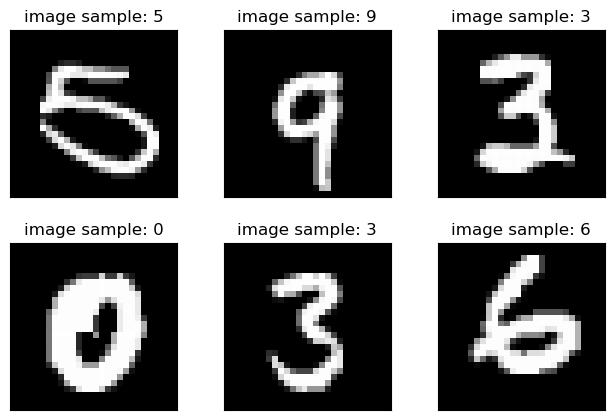

In [9]:
# step1. load dataset
import torch
from torch import nn 
from torch.nn import functional as F
from torch import optim

import torchvision
from matplotlib import pyplot as plt
from utils import plot_curve,plot_image,one_hot
import numpy as np

batch_size = 512
train_loader = torch.utils.data.DataLoader(
    dataset = torchvision.datasets.MNIST('mnist_data/',train=True,download=True,
                               transform=torchvision.transforms.Compose(
                                   [torchvision.transforms.ToTensor(),
                                    torchvision.transforms.Normalize((0.1307,),(0.3081,))] # 使得数据均匀分布在0附近，原本是0-1
                               )),
    batch_size = batch_size,
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('mnist_data/', train=False, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize((0.1307,), (0.3081,))]
                                   )),
    batch_size=batch_size, shuffle=False)

x,y = next(iter(train_loader))
print(x.shape ,y.shape, x.min(), x.max)
plot_image(x,y,'image sample')


In [10]:
# step2. build model

# pytorch实现
class Net_torch(nn.Module):
    def __init__(self):
        super(Net_torch, self).__init__()

        # xw+b
        self.fc1 = nn.Linear(28*28,256)# 线性层
        self.fc2 = nn.Linear(256,64)
        self.fc3 = nn.Linear(64,10)
    
    def forward(self, x):
        # x:[b,1,x,x]
        # h1 = relu(xw1+b1)
        x = F.relu(self.fc1(x))
        # h2 = relu(h1w2+b2)
        x = F.relu(self.fc2(x))
        # h3 = h2w3+b3
        x = self.fc3(x)
        return x


0 0 0.11455535888671875
0 10 0.09556237608194351
0 20 0.0856563001871109
0 30 0.07850505411624908
0 40 0.07252658903598785
0 50 0.06754559278488159
0 60 0.06472134590148926
0 70 0.059799693524837494
0 80 0.057250965386629105
0 90 0.05707051604986191
0 100 0.05323142930865288
0 110 0.05322366952896118
1 0 0.05162200331687927
1 10 0.048446252942085266
1 20 0.047059476375579834
1 30 0.046997763216495514
1 40 0.043524231761693954
1 50 0.044225290417671204
1 60 0.04233918339014053
1 70 0.042431820183992386
1 80 0.04107067361474037
1 90 0.03993665426969528
1 100 0.03965586796402931
1 110 0.036495912820100784
2 0 0.03694635257124901
2 10 0.03657195717096329
2 20 0.035592347383499146
2 30 0.037145473062992096
2 40 0.035787150263786316
2 50 0.0352005735039711
2 60 0.03486890718340874
2 70 0.03251536935567856
2 80 0.03538227453827858
2 90 0.03263381868600845
2 100 0.03353466838598251
2 110 0.03353697806596756


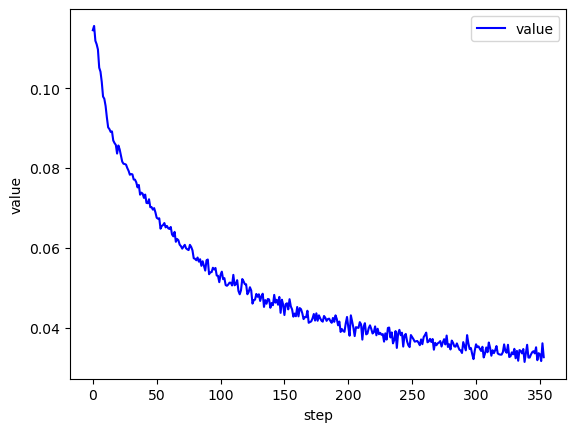

In [17]:
# step3. train model
net = Net_torch()
optimizer = optim.SGD(net.parameters(),lr=0.01,momentum=0.9)# 优化器，梯度下降优化器：lr：learningrate学习步长

train_loss = []
for epoch in range(3):
    for batch_idx,(x,y) in enumerate(train_loader):
        # x:[b,1,28,28],y:[512]
        # [b,1,28,28] => [b,feature]=[b,784]
        x = x.view(x.size(0),28*28)
        # => [b,10]
        out = net(x)
        y_onehot = one_hot(y)
        # loss = mse(out,y_onehot)
        loss = F.mse_loss(out,y_onehot)# 均方差

        optimizer.zero_grad() # 清零梯度
        loss.backward() # 计算梯度
        # w' = w - lr*grad
        optimizer.step() #更新
        
        train_loss.append(loss.item())
        if batch_idx % 10 == 0:
            print(epoch, batch_idx, loss.item())

plot_curve(train_loss)
# 得到比较好的 [w1,b1,w2,b2,w3,b3]

test acc:t 0.8874


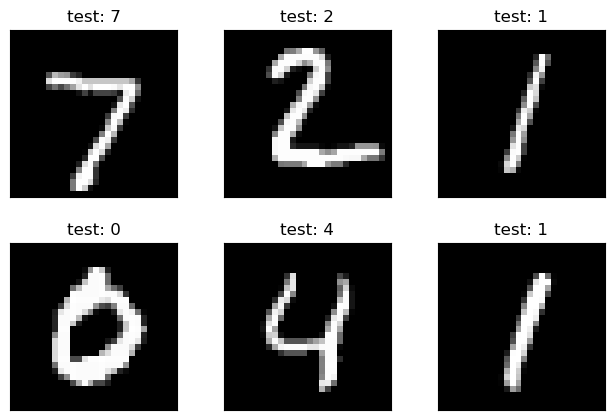

In [18]:
# step4. evaluate model
total_correct = 0
for x,y in test_loader:
    x = x.view(x.size(0),28*28)
    out = net(x)
    # out: [b:10]
    pred = out.argmax(dim=1)# 最大值所在的索引
    correct = pred.eq(y).sum().float().item()# 当前batch中正确的数量
    total_correct += correct

total_num = len(test_loader.dataset)
acc = total_correct/total_num
print('test acc:t',acc)

x, y = next(iter(test_loader))
out = net(x.view(x.size(0), 28*28))
pred = out.argmax(dim = 1)
plot_image(x, pred, 'test')